
# ЦОС — Лабораторная работа №1: Генерация тонов

Методичка (версия 2025.02.07) требует:

## 3.1 Генерация чистого тона
Реализовать `tone(f, t, waveform, fs)`:
- формы: **sin/cos**, **square (меандр, скважность 2)**, **triangle** (через `sawtooth(width=0.5)`), **sawtooth**  
- вернуть `numpy`-массив типа `np.float`, амплитуда **1** (от −1 до +1)  
- проверить:
  1) визуально — график (stem)  
  2) аудиально — сохранить в WAV

## 3.2 Затухающий составной тон
Реализовать `musical_tone(f, t, waveform, fs, db)`:
- сумма гармоник `f, 2f, 3f, ...`, последний обертон ≤ **20 кГц**
- амплитуда основного тона = 1, интенсивности обертонов — на выбор
- после суммирования **нормировать** сигнал до амплитуды 1
- затухание — умножение на правостороннюю экспоненту, параметр затухания вычислять из `t, fs, db`
- `db ≤ 0`, при `db = 0` затухания нет

## 3.3 Творческая часть
С помощью `musical_tone` собрать простую композицию **8–20 секунд** и сохранить в WAV.
Дополнительно в этом ноутбуке реализован парсер «мини-языка» для нот:
- `[ ... ]` → играть одновременно (аккорд)  
- без пробелов между нотами → играть быстро подряд  
- пробелы между нотами → играть с короткой паузой  
- `|` → пауза (пробелы вокруг/между `|` увеличивают длительность)  
- перенос строки / пустая строка → расширенная пауза


In [12]:

import enum
import re
from dataclasses import dataclass
from typing import List, Optional, Tuple

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt

from scipy import signal
from scipy.io import wavfile

DEFAULT_FREQUENCY_SAMPLING = 44100  # fs

NOTE_INDEX = {
    "C": 0, "C#": 1, "Db": 1,
    "D": 2, "D#": 3, "Eb": 3,
    "E": 4, "F": 5, "F#": 6, "Gb": 6,
    "G": 7, "G#": 8, "Ab": 8,
    "A": 9, "A#": 10, "Bb": 10,
    "B": 11,
}

NOTE_RE = re.compile(r"[A-G](?:#|b)?\d+")

In [13]:

def note_to_freq(note: str, a4: float = 440.0) -> float:
    m = re.fullmatch(r"([A-G](?:#|b)?)(\d+)", note.strip())
    if not m:
        raise ValueError(f"Некорректная нота: {note!r}")
    name, octave_str = m.group(1), m.group(2)
    if name not in NOTE_INDEX:
        raise ValueError(f"Неизвестная нота: {name!r}")
    octave = int(octave_str)
    midi = (octave + 1) * 12 + NOTE_INDEX[name]
    return a4 * 2 ** ((midi - 69) / 12)


In [14]:
class Waveform(enum.Enum):
    SIN = 0
    COS = 1
    SQUARE = 2
    TRIANGLE = 3
    SAWTOOTH = 4

In [15]:
def tone(
    frequency: float,
    duration: float,
    waveform: Waveform = Waveform.SIN,
    sampling_rate: int = DEFAULT_FREQUENCY_SAMPLING,
) -> npt.NDArray[np.float64]:
    """Чистый тон одной частоты. Амплитуда от -1 до +1."""

    n = int(round(duration * sampling_rate))
    if n <= 0:
        return np.zeros(0, dtype=np.float64)

    t = np.arange(n, dtype=np.float64) / sampling_rate
    phase = 2 * np.pi * frequency * t

    match waveform:
        case Waveform.SIN:
            x = np.sin(phase)
        case Waveform.COS:
            x = np.cos(phase)
        case Waveform.SQUARE:
            x = signal.square(phase)
        case Waveform.TRIANGLE:
            x = signal.sawtooth(phase, width=0.5)
        case Waveform.SAWTOOTH:
            x = signal.sawtooth(phase)
        case _:
            raise ValueError(f"Неизвестная форма: {waveform}")

    return x.astype(np.float64)

In [16]:

def musical_tone(
    fundamental_frequency: float,
    duration: float,
    waveform: Waveform = Waveform.SIN,
    sampling_rate: int = DEFAULT_FREQUENCY_SAMPLING,
    decay_db: float = -20,
    harmonic_weights: Optional[List[float]] = None,
    max_freq: float = 20000.0,
    default_harmonics: int = 8,
) -> npt.NDArray[np.float64]:
    if decay_db > 0:
        raise ValueError("decay_db должен быть <= 0 (0 — без затухания).")

    n = int(round(duration * sampling_rate))
    if n <= 0:
        return np.zeros(0, dtype=np.float64)

    max_harmonic = max(1, int(max_freq // fundamental_frequency))

    if harmonic_weights is None:
        harmonics_count = min(max_harmonic, default_harmonics)
        harmonic_weights = [1.0 / k for k in range(1, harmonics_count + 1)]
    else:
        harmonics_count = min(len(harmonic_weights), max_harmonic)
        harmonic_weights = harmonic_weights[:harmonics_count]

    x = np.zeros(n, dtype=np.float64)
    for k, w in enumerate(harmonic_weights, start=1):
        f = fundamental_frequency * k
        if f > max_freq:
            break
        x += w * tone(f, duration, waveform, sampling_rate)

    # Нормировка (амплитуда <= 1)
    mx = float(np.max(np.abs(x))) if x.size else 0.0
    if mx > 0:
        x /= mx

    # Затухание: в конце амплитуда = 10^(db/20)
    if decay_db < 0 and x.size:
        A_end = 10 ** (decay_db / 20)
        if n == 1:
            env = np.array([1.0], dtype=np.float64)
        else:
            a = A_end ** (1.0 / (n - 1))
            env = a ** np.arange(n, dtype=np.float64)
        x *= env

    return x


In [17]:

def play_chord(
    notes: List[str],
    duration: float,
    waveform: Waveform = Waveform.SIN,
    decay_db: float = -15,
    sampling_rate: int = DEFAULT_FREQUENCY_SAMPLING,
) -> npt.NDArray[np.float64]:
    """Аккорд: несколько нот одновременно."""
    n = int(round(duration * sampling_rate))
    mix = np.zeros(n, dtype=np.float64)
    for note in notes:
        mix += musical_tone(
            note_to_freq(note),
            duration,
            waveform=waveform,
            sampling_rate=sampling_rate,
            decay_db=decay_db,
        )
    mx = float(np.max(np.abs(mix))) if mix.size else 0.0
    if mx > 0:
        mix /= mx
    return mix


def rest(duration: float, sampling_rate: int = DEFAULT_FREQUENCY_SAMPLING) -> npt.NDArray[np.float64]:
    n = int(round(duration * sampling_rate))
    return np.zeros(max(n, 0), dtype=np.float64)


def plot_stem(x: npt.NDArray[np.float64], fs: int, ms: float = 5.0, title: str = "") -> None:
    n = min(len(x), int(round(ms / 1000.0 * fs)))
    t = np.arange(n) / fs
    plt.figure()
    plt.stem(t, x[:n])
    plt.title(title)
    plt.xlabel("t, s")
    plt.ylabel("амплитуда")
    plt.grid(True)
    plt.show()


## Проверка `tone`: графики (stem) и WAV для всех форм

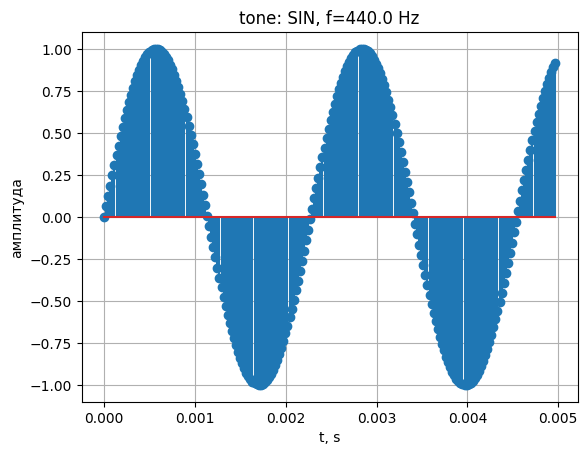

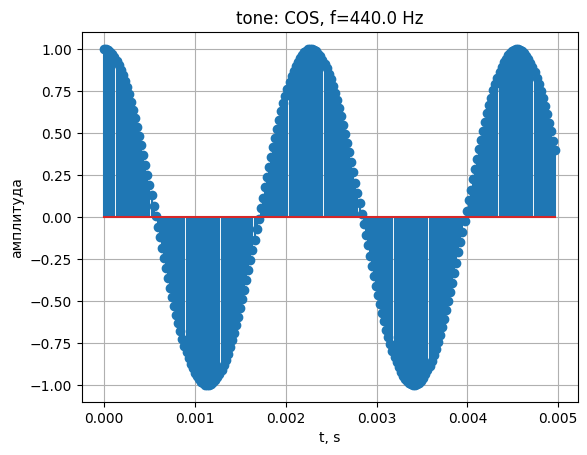

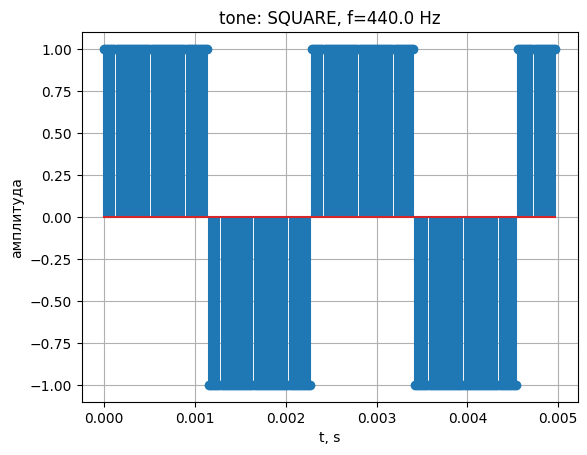

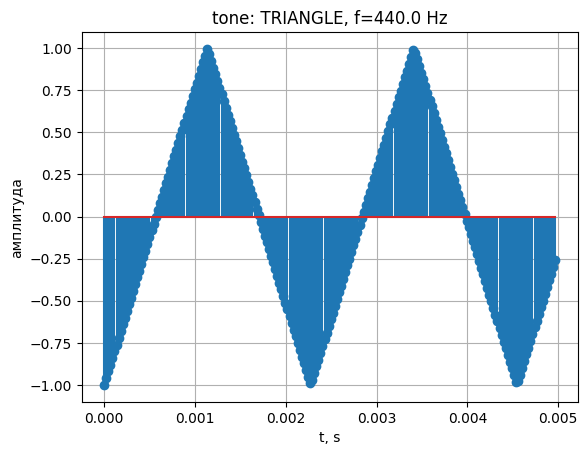

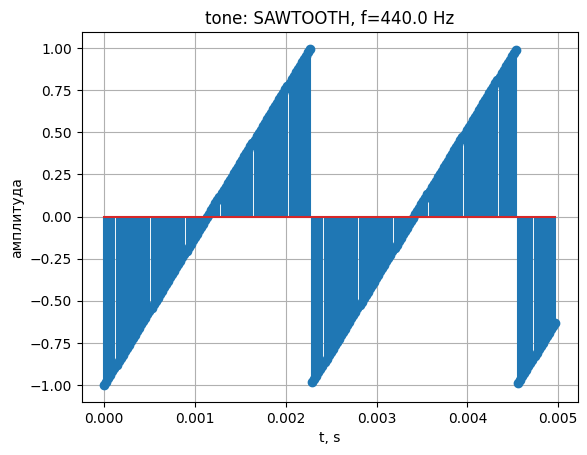

{'SIN': 'tone_SIN.wav',
 'COS': 'tone_COS.wav',
 'SQUARE': 'tone_SQUARE.wav',
 'TRIANGLE': 'tone_TRIANGLE.wav',
 'SAWTOOTH': 'tone_SAWTOOTH.wav'}

In [18]:

fs = DEFAULT_FREQUENCY_SAMPLING
f = 440.0   # A4
dur = 2.0   # секунды

tone_wavs = {}
for wf in Waveform:
    x = tone(f, dur, waveform=wf, sampling_rate=fs)
    plot_stem(x, fs, ms=5.0, title=f"tone: {wf.name}, f={f} Hz")
    fname = f"tone_{wf.name}.wav"
    wavfile.write(fname, fs, x.astype(np.float32))
    tone_wavs[wf.name] = fname

tone_wavs


## Проверка `musical_tone`: графики (stem) и WAV для всех форм

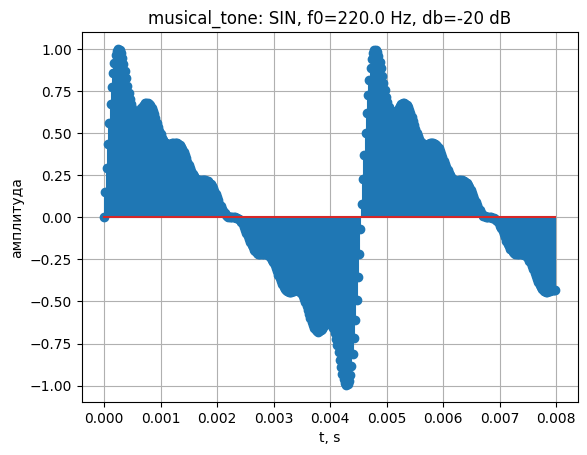

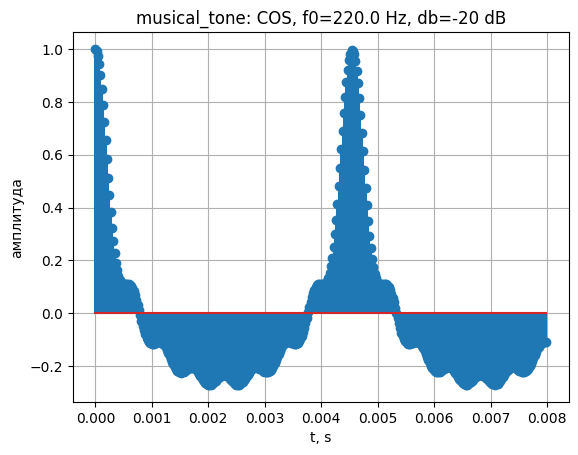

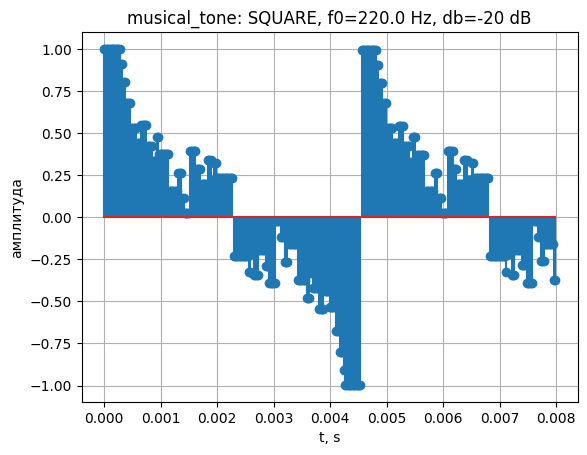

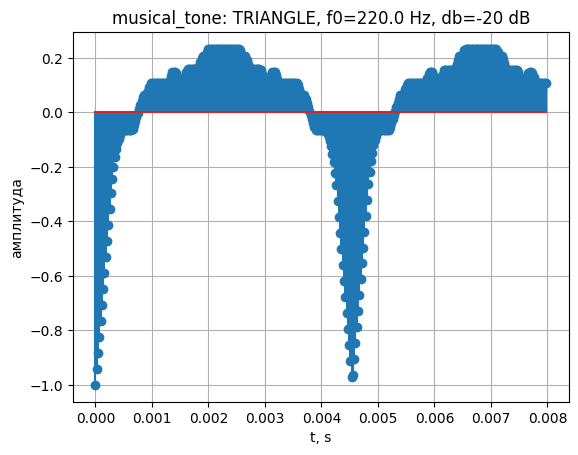

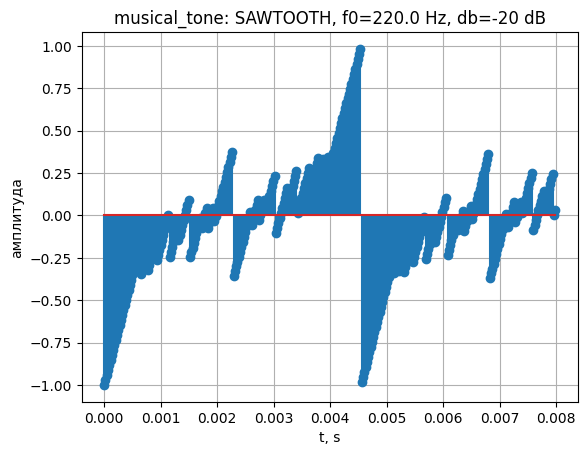

{'SIN': 'musical_SIN.wav',
 'COS': 'musical_COS.wav',
 'SQUARE': 'musical_SQUARE.wav',
 'TRIANGLE': 'musical_TRIANGLE.wav',
 'SAWTOOTH': 'musical_SAWTOOTH.wav'}

In [19]:

fs = DEFAULT_FREQUENCY_SAMPLING
f0 = 220.0
dur = 2.5
db = -20

mus_wavs = {}
for wf in Waveform:
    x = musical_tone(f0, dur, waveform=wf, sampling_rate=fs, decay_db=db)
    plot_stem(x, fs, ms=8.0, title=f"musical_tone: {wf.name}, f0={f0} Hz, db={db} dB")
    fname = f"musical_{wf.name}.wav"
    wavfile.write(fname, fs, x.astype(np.float32))
    mus_wavs[wf.name] = fname

mus_wavs


## Творческая часть: парсер мини-языка и генерация композиции

In [20]:

@dataclass(frozen=True)
class Event:
    kind: str                 # "note", "chord", "rest"
    notes: Tuple[str, ...]    # для note/chord, для rest пусто
    duration: float           # секунды


def _parse_pipe_pause_units(segment: str) -> int:
    left_spaces = len(segment) - len(segment.lstrip(" "))
    right_spaces = len(segment) - len(segment.rstrip(" "))
    core = segment.strip(" ")
    pipes = core.count("|")
    between_spaces_present = 1 if re.search(r"\|\s+\|", core) else 0
    units = 1 + left_spaces + right_spaces + 2 * max(0, pipes - 1) + between_spaces_present
    return max(units, 1)


def parse_score(
    text: str,
    *,
    note_duration: float = 0.35,       # длительность обычной ноты
    fast_ratio: float = 0.25,          # asdf -> очень быстро
    space_pause_ratio: float = 0.18,   # a s -> короткая пауза
    newline_pause_ratio: float = 0.70, # перенос строки -> расширенная пауза
    paragraph_pause_ratio: float = 2.2,# пустая строка -> extended pause
    pipe_unit_ratio: float = 0.60,     # единица паузы от | (в долях note_duration)
) -> List[Event]:
    events: List[Event] = []
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    i, n = 0, len(text)

    def emit_note(note: str, fast: bool) -> None:
        dur = note_duration * (fast_ratio if fast else 1.0)
        events.append(Event("note", (note,), dur))

    def emit_chord(notes: List[str], fast: bool) -> None:
        dur = note_duration * (fast_ratio if fast else 1.0)
        events.append(Event("chord", tuple(notes), dur))

    def emit_rest(seconds: float) -> None:
        if seconds > 0:
            events.append(Event("rest", tuple(), seconds))

    def peek_space_run(pos: int) -> int:
        k = pos
        while k < n and text[k] == " ":
            k += 1
        return k - pos

    while i < n:
        ch = text[i]

        if ch == "\n":
            j = i
            while j < n and text[j] == "\n":
                j += 1
            newlines = j - i
            emit_rest(note_duration * (paragraph_pause_ratio if newlines >= 2 else newline_pause_ratio))
            i = j
            continue

        if ch == " ":
            i += 1
            continue

        if ch == "|":
            start = i
            j = i
            while j < n:
                if text[j] == "|":
                    j += 1
                    while j < n and text[j] == " ":
                        j += 1
                    if j < n and text[j] == "|":
                        continue
                    break
                break
            segment = text[start:j]
            units = _parse_pipe_pause_units(segment)
            emit_rest(note_duration * pipe_unit_ratio * units)
            i = j
            continue

        if ch == "[":
            j = i + 1
            while j < n and text[j] != "]":
                j += 1
            if j >= n:
                raise ValueError("Не найдена закрывающая ']' для аккорда.")
            inside = text[i + 1:j]
            chord_notes = NOTE_RE.findall(inside)
            if not chord_notes:
                raise ValueError(f"Пустой аккорд: {text[i:j+1]!r}")

            fast = False
            if i > 0:
                prev = text[i - 1]
                fast = (prev not in [" ", "\n", "|", "["])

            emit_chord(chord_notes, fast=fast)
            i = j + 1
            continue

        m = NOTE_RE.match(text, i)
        if m:
            note = m.group(0)
            start = i
            end = m.end()

            fast = False
            if start > 0:
                prev_char = text[start - 1]
                fast = (prev_char not in [" ", "\n", "|", "["])

            emit_note(note, fast=fast)

            k = end
            spaces = peek_space_run(k)
            k2 = k + spaces
            if spaces > 0 and k2 < n and (NOTE_RE.match(text, k2) or text[k2] == "["):
                emit_rest(note_duration * space_pause_ratio)

            i = end
            continue

        raise ValueError(f"Неожиданный символ: {text[i]!r} (позиция {i})")

    return events


def render_events(
    events: List[Event],
    *,
    sampling_rate: int = DEFAULT_FREQUENCY_SAMPLING,
    waveform: Waveform = Waveform.SIN,
    decay_db: float = -12,
) -> npt.NDArray[np.float64]:
    parts: List[npt.NDArray[np.float64]] = []
    for ev in events:
        if ev.kind == "rest":
            parts.append(rest(ev.duration, sampling_rate))
        elif ev.kind == "note":
            parts.append(
                musical_tone(
                    note_to_freq(ev.notes[0]),
                    ev.duration,
                    waveform=waveform,
                    sampling_rate=sampling_rate,
                    decay_db=decay_db,
                )
            )
        elif ev.kind == "chord":
            parts.append(
                play_chord(
                    list(ev.notes),
                    ev.duration,
                    waveform=waveform,
                    decay_db=decay_db,
                    sampling_rate=sampling_rate,
                )
            )
        else:
            raise ValueError(f"Неизвестное событие: {ev}")

    if not parts:
        return np.zeros(0, dtype=np.float64)

    song = np.concatenate(parts)
    mx = float(np.max(np.abs(song))) if song.size else 0.0
    if mx > 0:
        song /= mx
    return song


In [21]:
score = """A3 A3A3 A3A3 A3A3A3A3A3 A3A3 A3A3 A3A3A3A3A3 A3A3 A3A3 A3A3E3G3A3 A3 A3B3C4 C4 C4D4B3 B3 A3G3G3A3|
E3G3A3 A3 A3B3C4 C4 C4D4B3 B3 A3G3A3|
E3G3A3 A3 A3C4D4 D4 D4E4F4 F4 E4D4E4A3|
A3B3C4 C4 D4 E4A3|A3C4B3 B3 C4A3B3|
E3G3A3 A3 A3B3C4 C4 C4D4B3 B3 A3G3G3A3|
E3G3A3 A3 A3B3C4 C4 C4D4B3 B3 A3G3A3|
E3G3A3 A3 A3C4D4 D4 D4E4F4 F4 E4D4E4A3|
A3B3C4 C4 D4 E4A3|
A3C4B3 B3 A3G3A3 A3 B3 C4 C4 D4 E4|
C4A3E3| F4| C4 F3| E4| F4 E4|
E4 E4 E4 F4E4| D4 D4 D4 D4E4| E4 E4 E4 F4E4|
D4 C4 B3 A3| A3B3C4|D4E4 D4 C4 B3 C4 D4 E4 D4| C4D4E4|
D4C4 B3 C4 B3 A3|B3G3 A3| A3B3C4|
B3C4 D4 C4 D4 E4 D4 C4 A3|
A3B3C4 D4 E4 F4 A3 D4 C4|D4B3 A3|B3G3
E4| F4| E4 E4 E4 E4D4|
D4| C4| B3 C4 B3 A3|
E4| F4| E4 E4 E4 E4D4|
D4| C4| B3 C4 B3 A3
""".strip("\n")

events = parse_score(score, note_duration=0.42)
song = render_events(events, waveform=Waveform.SIN, decay_db=-12)

duration_sec = len(song) / DEFAULT_FREQUENCY_SAMPLING
duration_sec


103.44031746031746

In [22]:

# Проверка длины: должно быть примерно 8–20 секунд (ориентир методички)
print(f"Длительность композиции: {duration_sec:.2f} сек")

wavfile.write("melody.wav", DEFAULT_FREQUENCY_SAMPLING, (song*32767).astype(np.int16))


Длительность композиции: 103.44 сек
